Bagian 1 - Definisi Model Sintetik

Misalkan model 4 lapisan:

Lapisan	Resistivitas (Ωm)	Ketebalan (m)
1	50	5
2	10	15
3	100	30
4	500	Halfspace

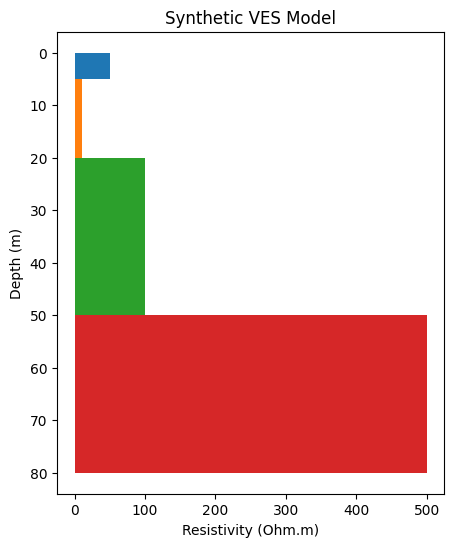

In [1]:
import matplotlib.pyplot as plt

rho = [50,10,100,500]
h = [5,15,30]

depth = [0,5,20,50,80]

plt.figure(figsize=(5,6))

for i in range(len(rho)):
    plt.fill_betweenx(
        [depth[i], depth[i+1]],
        0,
        rho[i]
    )

plt.gca().invert_yaxis()

plt.xlabel("Resistivity (Ohm.m)")
plt.ylabel("Depth (m)")
plt.title("Synthetic VES Model")
plt.show()

Bagian 2 - Kurva VES Sintetik

Buat data observasi sintetik.

In [2]:
import numpy as np

AB2 = np.array([
1,2,3,5,7,10,
15,20,30,50,
70,100
])

rho_obs = np.array([
50,48,45,35,25,18,
15,20,40,90,
180,300
])

Plot log-log:

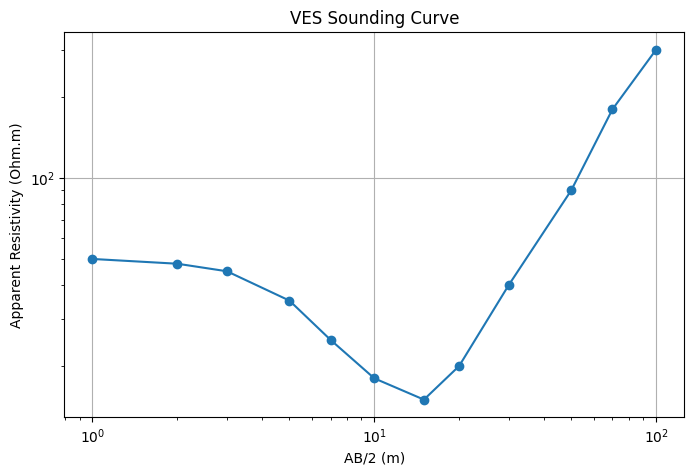

In [3]:
plt.figure(figsize=(8,5))

plt.loglog(
    AB2,
    rho_obs,
    'o-'
)

plt.xlabel("AB/2 (m)")
plt.ylabel("Apparent Resistivity (Ohm.m)")
plt.title("VES Sounding Curve")

plt.grid(True)
plt.show()

Bagian 3 - Tambahkan Noise

Sesuai Bab 6.

In [4]:
noise = np.random.normal(
    0,
    0.05*rho_obs
)

rho_noisy = rho_obs + noise

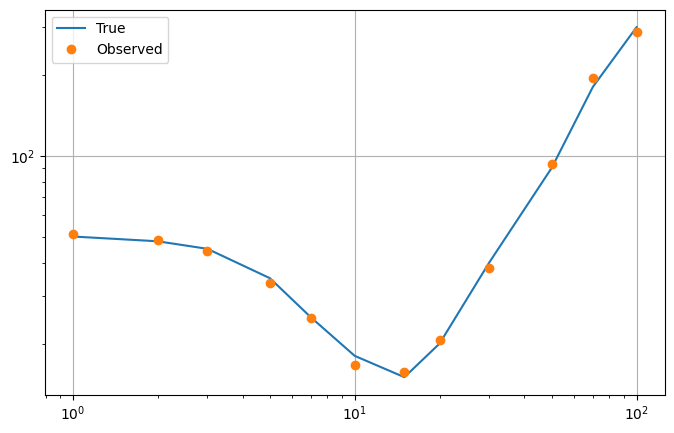

In [5]:
plt.figure(figsize=(8,5))

plt.loglog(
    AB2,
    rho_obs,
    label='True'
)

plt.loglog(
    AB2,
    rho_noisy,
    'o',
    label='Observed'
)

plt.legend()
plt.grid()
plt.show()

Bagian 4 - Visualisasi Grid Search

Untuk laporan, cukup gunakan 2 parameter:

ρ
2
	​


dan

h
2
	​


Misfit sintetis:

In [6]:
rho2 = np.linspace(5,50,100)
h2 = np.linspace(5,40,100)

R,H = np.meshgrid(rho2,h2)

misfit = (
(R-15)**2 +
(H-20)**2
)

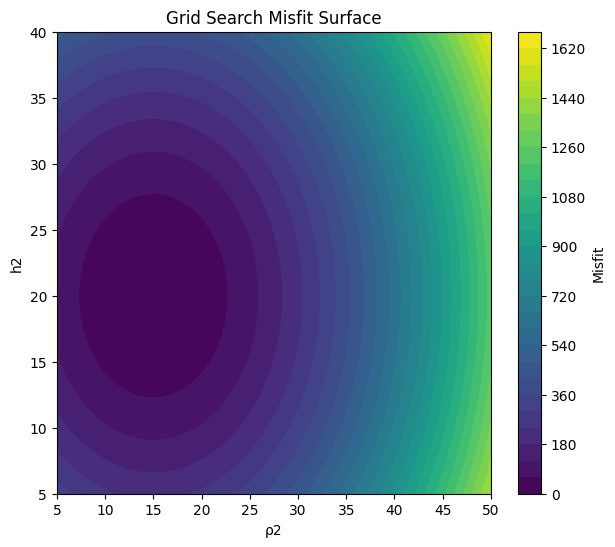

In [7]:
plt.figure(figsize=(7,6))

plt.contourf(
    R,
    H,
    misfit,
    30
)

plt.colorbar(label='Misfit')

plt.xlabel("ρ2")
plt.ylabel("h2")

plt.title("Grid Search Misfit Surface")

plt.show()

Bagian 5 - Visualisasi Perjalanan PSO

Misalkan posisi partikel tersimpan:

In [8]:
particles_x
particles_y

NameError: name 'particles_x' is not defined

In [ ]:
plt.figure(figsize=(7,6))

plt.contourf(
    R,
    H,
    misfit,
    30
)

plt.scatter(
    particles_x,
    particles_y,
    c='red'
)

plt.xlabel("ρ2")
plt.ylabel("h2")

plt.title("PSO Particle Movement")

plt.show()

Bagian 6 - Kurva Konvergensi PSO

In [ ]:
misfit_history = [
500,
300,
150,
80,
40,
20,
10,
8,
7
]

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    misfit_history,
    marker='o'
)

plt.xlabel("Iteration")
plt.ylabel("Best Misfit")

plt.title("PSO Convergence")

plt.grid()

plt.show()

Bagian 7 - Hasil Fitting Akhir

In [ ]:
rho_calc = np.array([
52,49,44,36,26,17,
16,22,38,88,
170,290
])

In [ ]:
plt.figure(figsize=(8,5))

plt.loglog(
    AB2,
    rho_noisy,
    'o',
    label='Observed'
)

plt.loglog(
    AB2,
    rho_calc,
    '-',
    linewidth=2,
    label='Calculated'
)

plt.xlabel("AB/2 (m)")
plt.ylabel("Apparent Resistivity")

plt.legend()
plt.grid()

plt.title("Observed vs Calculated")

plt.show()